In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("Mini-Courier Planner setup successful!")
print("Pandas version:", pd.__version__)
print("NetworkX version:", nx.__version__)

Mini-Courier Planner setup successful!
Pandas version: 3.0.6
NetworkX version: 3.7


In [89]:

parcels = pd.read_csv("datasets/parcels.csv")
routes = pd.read_csv("datasets/routes.csv")

print("PARCEL DATA")
display(parcels)

print("\nROUTE DATA")
display(routes)

PARCEL DATA


,parcel_id,weight,value,priority,deadline,destination
0,P01,5,100,9,2,A
1,P02,3,80,7,3,B
2,P03,8,120,6,5,C
3,P04,2,60,10,1,D
4,P05,6,150,8,4,E
5,P06,4,90,5,6,A
6,P07,7,130,9,3,C
7,P08,3,70,4,7,B
8,P09,5,110,8,2,D
9,P10,2,50,6,5,E



ROUTE DATA


,source,destination,distance
0,Warehouse,A,5
1,Warehouse,B,8
2,A,C,4
3,B,C,2
4,B,D,6
5,C,D,3
6,C,E,7
7,D,E,2
8,A,B,6


In [90]:

G = nx.Graph()

for _, row in routes.iterrows():
    G.add_edge(
        row["source"],
        row["destination"],
        weight=row["distance"]
    )

print("Nodes:", list(G.nodes))
print("Edges:", list(G.edges(data=True)))

Nodes: ['Warehouse', 'A', 'B', 'C', 'D', 'E']
Edges: [('Warehouse', 'A', {'weight': 5}), ('Warehouse', 'B', {'weight': 8}), ('A', 'C', {'weight': 4}), ('A', 'B', {'weight': 6}), ('B', 'C', {'weight': 2}), ('B', 'D', {'weight': 6}), ('C', 'D', {'weight': 3}), ('C', 'E', {'weight': 7}), ('D', 'E', {'weight': 2})]


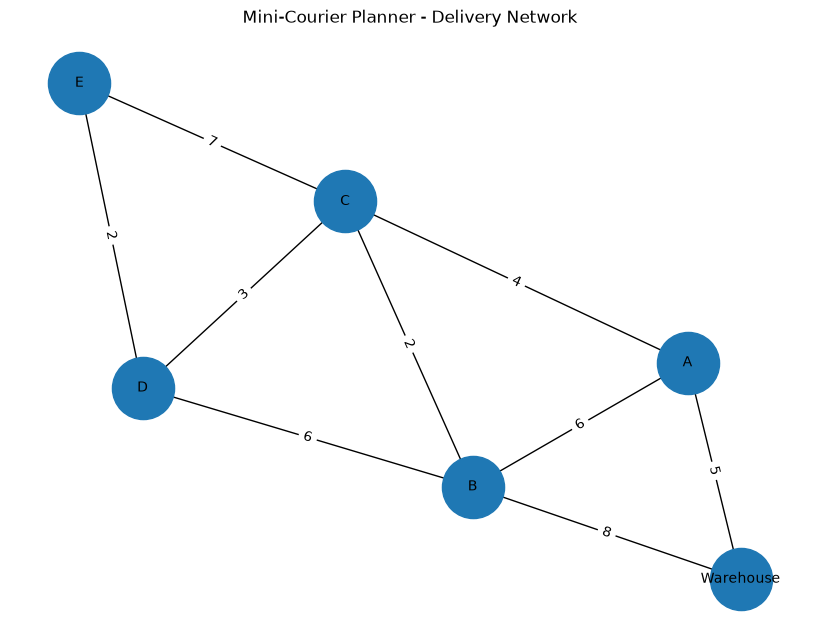

In [91]:


plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=10
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Mini-Courier Planner - Delivery Network")
plt.show()

In [92]:
from src.sorting import merge_sort

parcel_list = parcels.to_dict("records")

sorted_parcels = merge_sort(parcel_list)

print("Parcels sorted by priority:\n")

for parcel in sorted_parcels:
    print(
        parcel["parcel_id"],
        "-> Priority:", parcel["priority"],
        "| Weight:", parcel["weight"],
        "| Value:", parcel["value"],
        "| Destination:", parcel["destination"]
    )

Parcels sorted by priority:

P04 -> Priority: 10 | Weight: 2 | Value: 60 | Destination: D
P12 -> Priority: 10 | Weight: 4 | Value: 100 | Destination: C
P14 -> Priority: 9 | Weight: 3 | Value: 75 | Destination: E
P01 -> Priority: 9 | Weight: 5 | Value: 100 | Destination: A
P07 -> Priority: 9 | Weight: 7 | Value: 130 | Destination: C
P09 -> Priority: 8 | Weight: 5 | Value: 110 | Destination: D
P05 -> Priority: 8 | Weight: 6 | Value: 150 | Destination: E
P02 -> Priority: 7 | Weight: 3 | Value: 80 | Destination: B
P15 -> Priority: 7 | Weight: 5 | Value: 115 | Destination: B
P11 -> Priority: 7 | Weight: 9 | Value: 160 | Destination: A
P10 -> Priority: 6 | Weight: 2 | Value: 50 | Destination: E
P03 -> Priority: 6 | Weight: 8 | Value: 120 | Destination: C
P06 -> Priority: 5 | Weight: 4 | Value: 90 | Destination: A
P13 -> Priority: 5 | Weight: 6 | Value: 140 | Destination: D
P08 -> Priority: 4 | Weight: 3 | Value: 70 | Destination: B


In [93]:


CAPACITY = 15

print("Vehicle Capacity:", CAPACITY, "kg")

Vehicle Capacity: 15 kg


In [94]:

from src.knapsack import knapsack

selected_parcels, dp_table = knapsack(
    sorted_parcels,
    CAPACITY
)

print("Selected Parcels:")

for parcel in selected_parcels:
    print(
        parcel["parcel_id"],
        "-> Weight:", parcel["weight"],
        "| Value:", parcel["value"],
        "| Priority:", parcel["priority"]
    )

total_weight = sum(
    parcel["weight"]
    for parcel in selected_parcels
)

total_value = sum(
    parcel["value"]
    for parcel in selected_parcels
)

print("\nTotal Weight:", total_weight, "kg")
print("Total Value:", total_value)
print("Vehicle Capacity:", CAPACITY, "kg")

Selected Parcels:
P04 -> Weight: 2 | Value: 60 | Priority: 10
P12 -> Weight: 4 | Value: 100 | Priority: 10
P05 -> Weight: 6 | Value: 150 | Priority: 8
P02 -> Weight: 3 | Value: 80 | Priority: 7

Total Weight: 15 kg
Total Value: 390
Vehicle Capacity: 15 kg


In [95]:


dp_df = pd.DataFrame(
    dp_table,
    columns=range(CAPACITY + 1)
)

dp_df.index.name = "Number of Parcels"

display(dp_df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Number of Parcels,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,60,60,60,60,60,60,60,60,60,60,60,60,60,60
2,0,0,60,60,100,100,160,160,160,160,160,160,160,160,160,160
3,0,0,60,75,100,135,160,175,175,235,235,235,235,235,235,235
4,0,0,60,75,100,135,160,175,175,235,235,260,275,275,335,335
5,0,0,60,75,100,135,160,175,175,235,235,260,275,290,335,335
6,0,0,60,75,100,135,160,175,185,235,245,270,285,290,345,345
7,0,0,60,75,100,135,160,175,210,235,250,285,310,325,345,385
8,0,0,60,80,100,140,160,180,215,240,255,290,315,330,365,390


In [96]:


from src.dijkstra import dijkstra, get_shortest_path

# Select unique destinations from selected parcels
selected_destinations = list(
    dict.fromkeys(
        parcel["destination"]
        for parcel in selected_parcels
    )
)

# Convert NetworkX graph into adjacency list
dijkstra_graph = {
    node: []
    for node in G.nodes
}

for node in G.nodes:

    for neighbor in G.neighbors(node):

        weight = G[node][neighbor]["weight"]

        dijkstra_graph[node].append(
            (neighbor, weight)
        )

# Run Dijkstra from Warehouse
distances, previous = dijkstra(
    dijkstra_graph,
    "Warehouse"
)

print("Shortest Paths from Warehouse:\n")

for destination in selected_destinations:

    path = get_shortest_path(
        previous,
        "Warehouse",
        destination
    )

    print(
        " → ".join(path),
        "| Distance:",
        distances[destination],
        "km"
    )

Shortest Paths from Warehouse:

Warehouse → A → C → D | Distance: 12 km
Warehouse → A → C | Distance: 9 km
Warehouse → A → C → D → E | Distance: 14 km
Warehouse → B | Distance: 8 km


In [97]:

from src.tsp import nearest_neighbor_tsp

# Convert NetworkX graph into adjacency list
tsp_graph = {
    node: []
    for node in G.nodes
}

for node in G.nodes:
    for neighbor in G.neighbors(node):
        weight = G[node][neighbor]["weight"]

        tsp_graph[node].append(
            (neighbor, weight)
        )


# Generate final delivery route
final_route, total_route_distance = nearest_neighbor_tsp(
    tsp_graph,
    "Warehouse",
    selected_destinations
)


print("Final Delivery Route:")
print(" → ".join(final_route))

print(
    "\nTotal Route Distance:",
    total_route_distance,
    "km"
)

Final Delivery Route:
Warehouse → B → C → D → E → D → C → A → Warehouse

Total Route Distance: 29 km


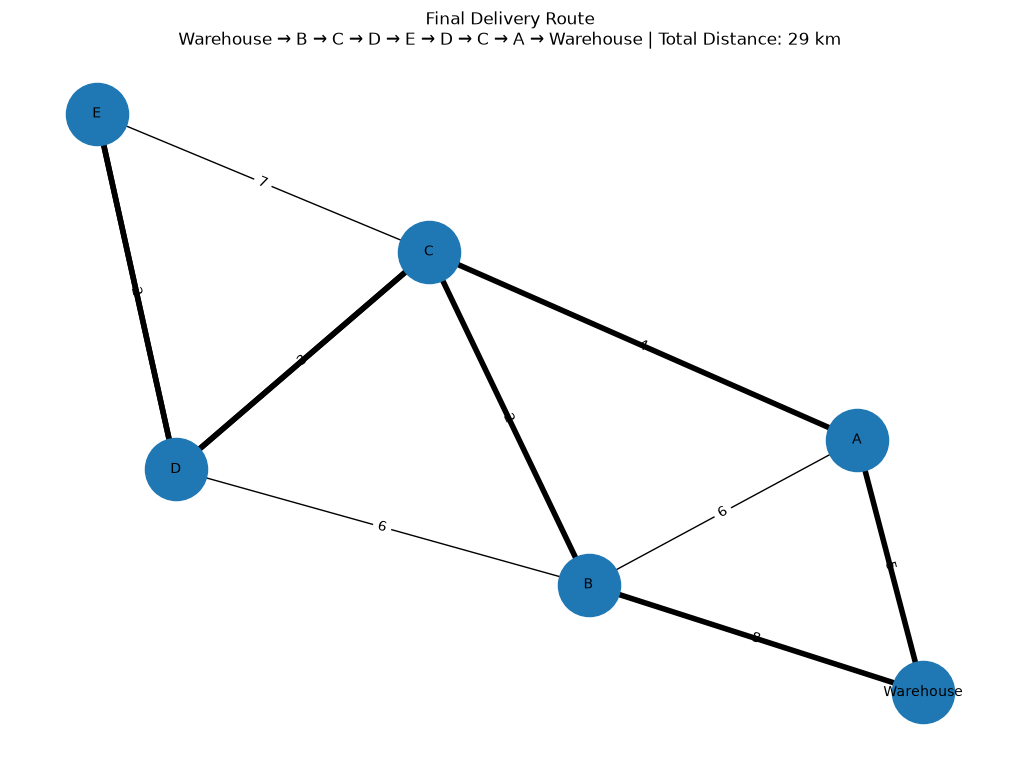

In [98]:

plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G, seed=42)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=10
)

# Draw edge distances
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

# Create route edges
route_edges = list(zip(final_route[:-1], final_route[1:]))

# Highlight final delivery route
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=route_edges,
    width=4
)

plt.title(
    f"Final Delivery Route\n"
    f"{' → '.join(final_route)} | "
    f"Total Distance: {total_route_distance} km"
)

# Save route visualization
plt.savefig(
    "images/route_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
# Performance measurement setup

from src.performance import measure_time

print("Performance testing setup ready!")

Performance testing setup ready!


In [100]:

import random

random.seed(42)

# Generate random parcel data

def generate_test_parcels(n):
    test_parcels = []

    for i in range(1, n + 1):
        test_parcels.append({
            "parcel_id": f"P{i:04d}",
            "weight": random.randint(1, 10),
            "value": random.randint(50, 200),
            "priority": random.randint(1, 10),
            "deadline": random.randint(1, 10),
            "destination": random.choice(["A", "B", "C", "D", "E"])
        })

    return test_parcels


test_sizes = [10, 25, 50, 100, 200]

test_datasets = {
    size: generate_test_parcels(size)
    for size in test_sizes
}

for size in test_sizes:
    print(f"{size} parcels -> {len(test_datasets[size])} records")

10 parcels -> 10 records
25 parcels -> 25 records
50 parcels -> 50 records
100 parcels -> 100 records
200 parcels -> 200 records


In [101]:

sorting_results = []

for size in test_sizes:

    data = test_datasets[size]

    _, runtime = measure_time(
        merge_sort,
        data
    )

    sorting_results.append({
        "Input Size": size,
        "Sorting Runtime (seconds)": runtime
    })

sorting_df = pd.DataFrame(sorting_results)

display(sorting_df)

,Input Size,Sorting Runtime (seconds)
0,10,0.000071
1,25,0.000096
2,50,0.000201
3,100,0.000346
4,200,0.000613


In [102]:

knapsack_results = []

for size in test_sizes:

    data = test_datasets[size]

    _, runtime = measure_time(
        knapsack,
        data,
        CAPACITY
    )

    knapsack_results.append({
        "Input Size": size,
        "Knapsack Runtime (seconds)": runtime
    })

knapsack_df = pd.DataFrame(knapsack_results)

display(knapsack_df)

,Input Size,Knapsack Runtime (seconds)
0,10,0.000058
1,25,0.000112
2,50,0.000622
3,100,0.000420
4,200,0.000829


In [103]:
dijkstra_results = []

# Create scalable graphs for different input sizes
scalable_graphs = {}

for size in test_sizes:

    graph = nx.Graph()

    for i in range(size):
        graph.add_node(i)

    for i in range(size - 1):
        graph.add_edge(
            i,
            i + 1,
            weight=1
        )

    scalable_graphs[size] = graph


for size, graph in scalable_graphs.items():

    # Convert NetworkX graph into adjacency list
    graph_data = {
        node: []
        for node in graph.nodes
    }

    for node in graph.nodes:

        for neighbor in graph.neighbors(node):

            weight = graph[node][neighbor]["weight"]

            graph_data[node].append(
                (neighbor, weight)
            )

    _, runtime = measure_time(
        dijkstra,
        graph_data,
        0
    )

    dijkstra_results.append({
        "Input Size": size,
        "Dijkstra Runtime (seconds)": runtime
    })


dijkstra_df = pd.DataFrame(dijkstra_results)

display(dijkstra_df)

,Input Size,Dijkstra Runtime (seconds)
0,10,0.000019
1,25,0.000025
2,50,0.000043
3,100,0.000086
4,200,0.000169


In [104]:
tsp_results = []

# Smaller sizes for TSP because it performs
# repeated shortest-path calculations
tsp_test_sizes = [10, 25, 50, 100, 200]

for size in tsp_test_sizes:

    graph = nx.Graph()

    for i in range(size):
        graph.add_node(i)

    for i in range(size - 1):
        graph.add_edge(
            i,
            i + 1,
            weight=1
        )

    graph_data = {
        node: []
        for node in graph.nodes
    }

    for node in graph.nodes:

        for neighbor in graph.neighbors(node):

            weight = graph[node][neighbor]["weight"]

            graph_data[node].append(
                (neighbor, weight)
            )

    destinations = list(graph.nodes)[1:]

    _, runtime = measure_time(
        nearest_neighbor_tsp,
        graph_data,
        0,
        destinations
    )

    tsp_results.append({
        "Input Size": size,
        "TSP Runtime (seconds)": runtime
    })


tsp_df = pd.DataFrame(tsp_results)

display(tsp_df)

,Input Size,TSP Runtime (seconds)
0,10,0.000426
1,25,0.005612
2,50,0.036762
3,100,0.348104
4,200,2.815645


In [105]:
performance_df = sorting_df.merge(
    knapsack_df,
    on="Input Size",
    how="outer"
)

performance_df = performance_df.merge(
    dijkstra_df,
    on="Input Size",
    how="outer"
)

performance_df = performance_df.merge(
    tsp_df,
    on="Input Size",
    how="outer"
)

performance_df = performance_df.sort_values(
    "Input Size"
).reset_index(drop=True)

display(performance_df)

performance_df.to_csv(
    "images/performance_results.csv",
    index=False
)

print("Performance results saved successfully!")

,Input Size,Sorting Runtime (seconds),Knapsack Runtime (seconds),Dijkstra Runtime (seconds),TSP Runtime (seconds)
0,10,0.000071,0.000058,0.000019,0.000426
1,25,0.000096,0.000112,0.000025,0.005612
2,50,0.000201,0.000622,0.000043,0.036762
3,100,0.000346,0.000420,0.000086,0.348104
4,200,0.000613,0.000829,0.000169,2.815645


Performance results saved successfully!


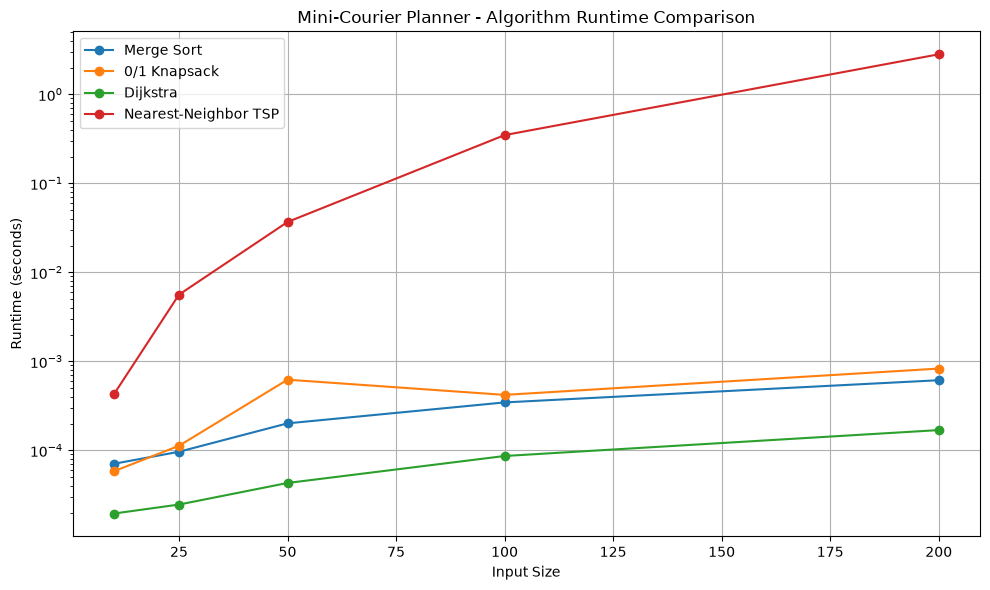

In [106]:
plt.figure(figsize=(10, 6))

plt.plot(
    performance_df["Input Size"],
    performance_df["Sorting Runtime (seconds)"],
    marker="o",
    label="Merge Sort"
)

plt.plot(
    performance_df["Input Size"],
    performance_df["Knapsack Runtime (seconds)"],
    marker="o",
    label="0/1 Knapsack"
)

plt.plot(
    performance_df["Input Size"],
    performance_df["Dijkstra Runtime (seconds)"],
    marker="o",
    label="Dijkstra"
)

plt.plot(
    performance_df["Input Size"],
    performance_df["TSP Runtime (seconds)"],
    marker="o",
    label="Nearest-Neighbor TSP"
)

plt.xlabel("Input Size")
plt.ylabel("Runtime (seconds)")
plt.title("Mini-Courier Planner - Algorithm Runtime Comparison")

plt.yscale("log")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "images/runtime_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Phase 4 — Performance Analysis

### Runtime Observations

The Mini-Courier Planner was tested using different input sizes.

- Merge Sort was tested with increasing numbers of parcels.
- 0/1 Knapsack was tested with increasing numbers of parcels while vehicle capacity remained fixed.
- Dijkstra was tested with graphs containing different numbers of nodes.
- Nearest-Neighbor TSP was tested with input sizes of 10, 25, 50, 100, and 200 because its implementation performs repeated shortest-path calculations.
- Runtime generally increased as the input size increased, showing the performance behavior of the implemented algorithms.
- The runtime comparison is visualized in the performance chart.

### Complexity Analysis

| Algorithm | Time Complexity | Space Complexity |
|---|---|---|
| Merge Sort | O(n log n) | O(n) |
| 0/1 Knapsack | O(n × W) | O(n × W) |
| Dijkstra | O((V + E) log V) | O(V) |
| Nearest-Neighbor TSP | O(V² × (V + E) log V) approximately | O(V + E) |

### Optimization and Performance Considerations

- Dijkstra uses a priority queue implemented with `heapq` for efficient shortest-path processing.
- Previously calculated shortest paths can be cached to reduce repeated computations in the TSP process.
- Efficient graph and data structures can be used for larger datasets.
- TSP was benchmarked separately with smaller input sizes because its repeated shortest-path calculations require more computation for larger graphs.
- Runtime measurements can be repeated with larger datasets to identify performance bottlenecks.

In [107]:
print("=" * 50)
print("       MINI-COURIER PLANNER")
print("=" * 50)

# 1. Load data
parcels = pd.read_csv("datasets/parcels.csv")
routes = pd.read_csv("datasets/routes.csv")

print("\n[1] DATA LOADED")
print("Parcels:", len(parcels))
print("Routes:", len(routes))


# 2. Build delivery graph
G = nx.Graph()

for _, row in routes.iterrows():
    G.add_edge(
        row["source"],
        row["destination"],
        weight=row["distance"]
    )

print("\n[2] DELIVERY GRAPH CREATED")
print("Locations:", list(G.nodes))


# 3. Prioritize parcels
parcel_list = parcels.to_dict("records")
sorted_parcels = merge_sort(parcel_list)

print("\n[3] PRIORITIZED PARCELS")

for parcel in sorted_parcels:
    print(
        parcel["parcel_id"],
        "| Priority:", parcel["priority"],
        "| Deadline:", parcel["deadline"]
    )


# 4. Select parcels using 0/1 Knapsack
CAPACITY = 15

selected_parcels, dp_table = knapsack(
    sorted_parcels,
    CAPACITY
)

total_weight = sum(
    parcel["weight"]
    for parcel in selected_parcels
)

total_value = sum(
    parcel["value"]
    for parcel in selected_parcels
)

print("\n[4] OPTIMAL PACKING")

for parcel in selected_parcels:
    print(
        parcel["parcel_id"],
        "| Weight:", parcel["weight"],
        "| Value:", parcel["value"]
    )

print("Total Weight:", total_weight, "kg")
print("Total Value:", total_value)


# 5. Identify delivery destinations
selected_destinations = list(
    dict.fromkeys(
        parcel["destination"]
        for parcel in selected_parcels
    )
)

print("\n[5] SELECTED CUSTOMERS")
print(selected_destinations)


# 6. Find shortest paths using Dijkstra
dijkstra_graph = {
    node: []
    for node in G.nodes
}

for node in G.nodes:
    for neighbor in G.neighbors(node):
        weight = G[node][neighbor]["weight"]

        dijkstra_graph[node].append(
            (neighbor, weight)
        )

distances, previous = dijkstra(
    dijkstra_graph,
    "Warehouse"
)

print("\n[6] SHORTEST PATHS")

for destination in selected_destinations:
    path = get_shortest_path(
        previous,
        "Warehouse",
        destination
    )

    print(
        " → ".join(path),
        "| Distance:",
        distances[destination],
        "km"
    )


# 7. Generate final delivery route
tsp_graph = {
    node: []
    for node in G.nodes
}

for node in G.nodes:
    for neighbor in G.neighbors(node):
        weight = G[node][neighbor]["weight"]

        tsp_graph[node].append(
            (neighbor, weight)
        )

final_route, total_route_distance = nearest_neighbor_tsp(
    tsp_graph,
    "Warehouse",
    selected_destinations
)

print("\n[7] FINAL DELIVERY ROUTE")
print(" → ".join(final_route))
print("Total Route Distance:", total_route_distance, "km")


# Final summary
print("\n" + "=" * 50)
print("             FINAL RESULT")
print("=" * 50)

print("Selected Parcels:", len(selected_parcels))
print("Total Weight:", total_weight, "kg")
print("Total Value:", total_value)
print("Customers:", selected_destinations)
print("Route:", " → ".join(final_route))
print("Route Distance:", total_route_distance, "km")

print("=" * 50)

       MINI-COURIER PLANNER

[1] DATA LOADED
Parcels: 15
Routes: 9

[2] DELIVERY GRAPH CREATED
Locations: ['Warehouse', 'A', 'B', 'C', 'D', 'E']

[3] PRIORITIZED PARCELS
P04 | Priority: 10 | Deadline: 1
P12 | Priority: 10 | Deadline: 2
P14 | Priority: 9 | Deadline: 1
P01 | Priority: 9 | Deadline: 2
P07 | Priority: 9 | Deadline: 3
P09 | Priority: 8 | Deadline: 2
P05 | Priority: 8 | Deadline: 4
P02 | Priority: 7 | Deadline: 3
P15 | Priority: 7 | Deadline: 4
P11 | Priority: 7 | Deadline: 6
P10 | Priority: 6 | Deadline: 5
P03 | Priority: 6 | Deadline: 5
P06 | Priority: 5 | Deadline: 6
P13 | Priority: 5 | Deadline: 8
P08 | Priority: 4 | Deadline: 7

[4] OPTIMAL PACKING
P04 | Weight: 2 | Value: 60
P12 | Weight: 4 | Value: 100
P05 | Weight: 6 | Value: 150
P02 | Weight: 3 | Value: 80
Total Weight: 15 kg
Total Value: 390

[5] SELECTED CUSTOMERS
['D', 'C', 'E', 'B']

[6] SHORTEST PATHS
Warehouse → A → C → D | Distance: 12 km
Warehouse → A → C | Distance: 9 km
Warehouse → A → C → D → E | Distance